Assignment 1: Jonah Hartmann


Task 1: Data Import and Exploration (4 Points)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


In [2]:
# load data
vax_df = pd.read_csv("filtered_vacancies_dataset_uruguay.csv")
print("This is the shape of the dataset:", vax_df.shape)
print("These are the columns in the dataset:", vax_df.columns)

This is the shape of the dataset: (28631, 30)
These are the columns in the dataset: Index(['year', 'EdadDesde', 'EdadHasta', 'CantidadPuestosVacantes',
       'Confidencial', 'AreaEstudio1', 'IdIdioma1', 'isco_2dig_pred', 'Sexo',
       'JornadaLaboral', 'NombreNivelJerarquico', 'num_words',
       'highest_GradoEstudio', 'section_ciiu', 'cogn_core', 'cogn_soph',
       'cogn_comp', 'cogn_software', 'cogn_mlai', 'cogn_finance',
       'cogn_writing', 'cogn_manage', 'social_character', 'social_social',
       'social_peoplemanage', 'social_customer', 'manual_fingerdexterity',
       'manual_coordination', 'manual_physical', 'Sueldo'],
      dtype='object')


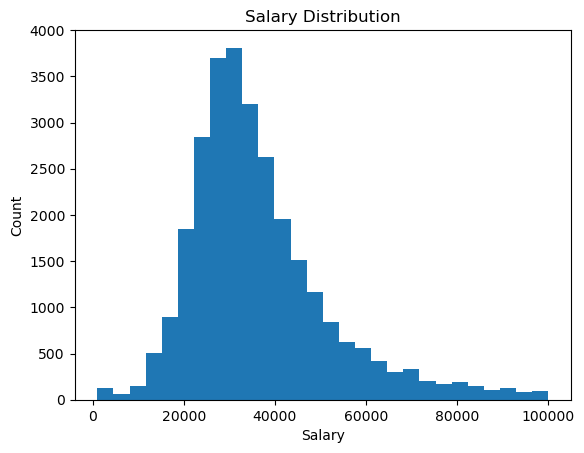

In [3]:
# visualize the distribution of the data
plt.hist(vax_df["Sueldo"], bins=28)
plt.xlabel('Salary')  # X-axis label
plt.ylabel('Count')   # Y-axis label
plt.title('Salary Distribution')  # Optional: adds a title
plt.show()

In [4]:
vax_df.describe()

categorical_features = [col for col in vax_df.columns if vax_df[col].dtype == "object"]
continuous_features = [col for col in vax_df.columns if col not in categorical_features]

Histograms for continuous features



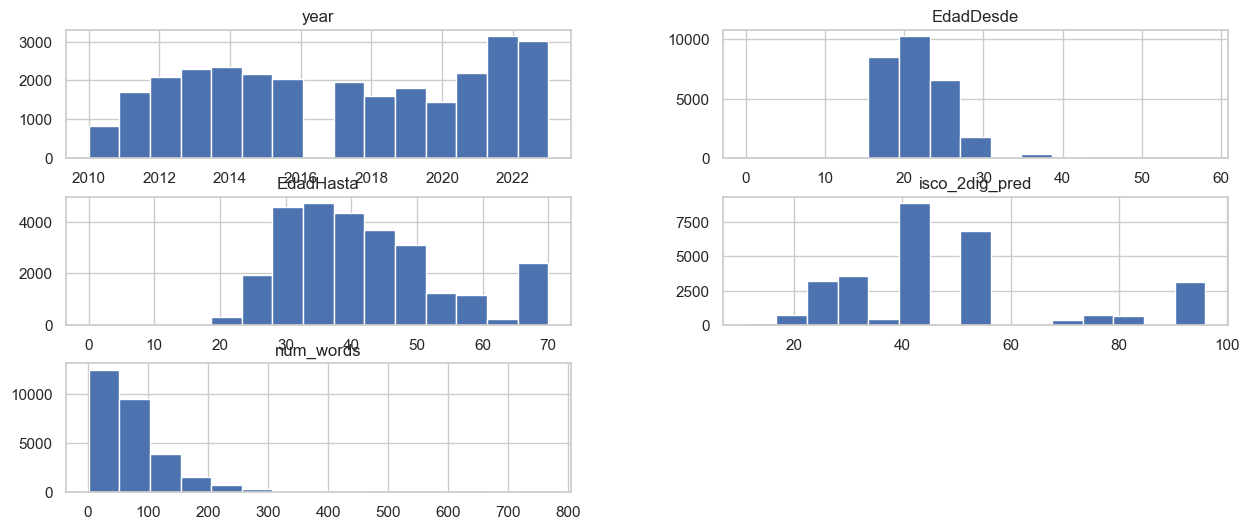

Count plots for categorical features



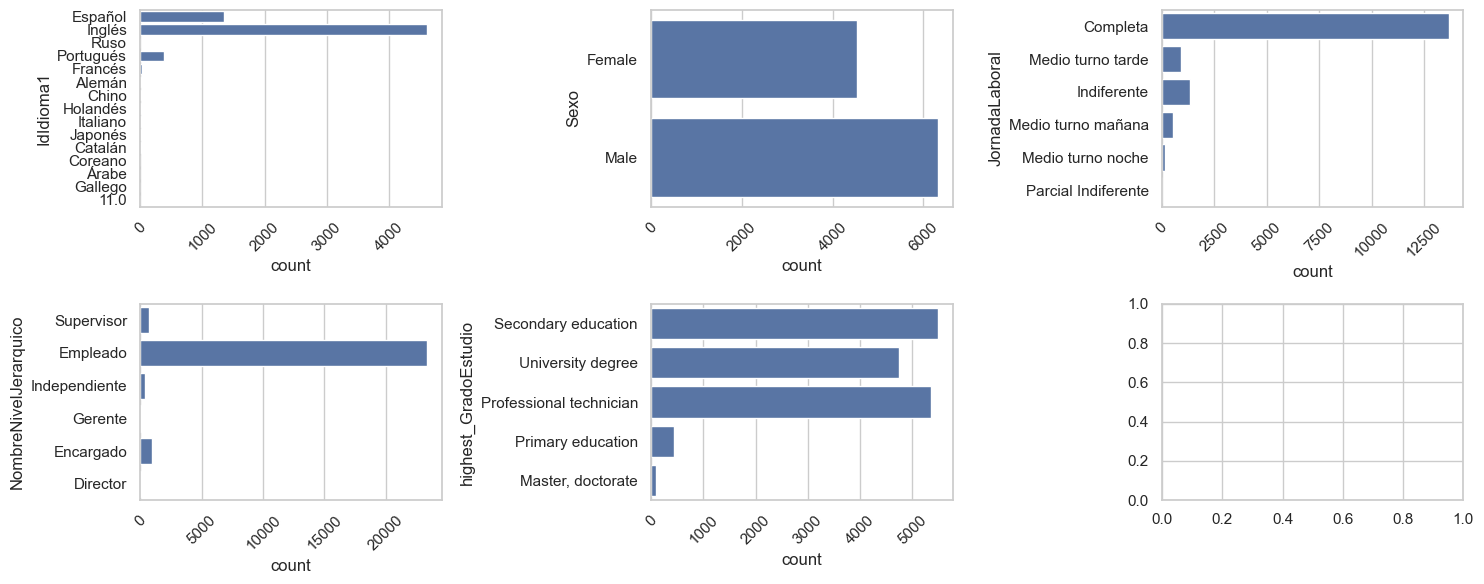

Correlation matrix



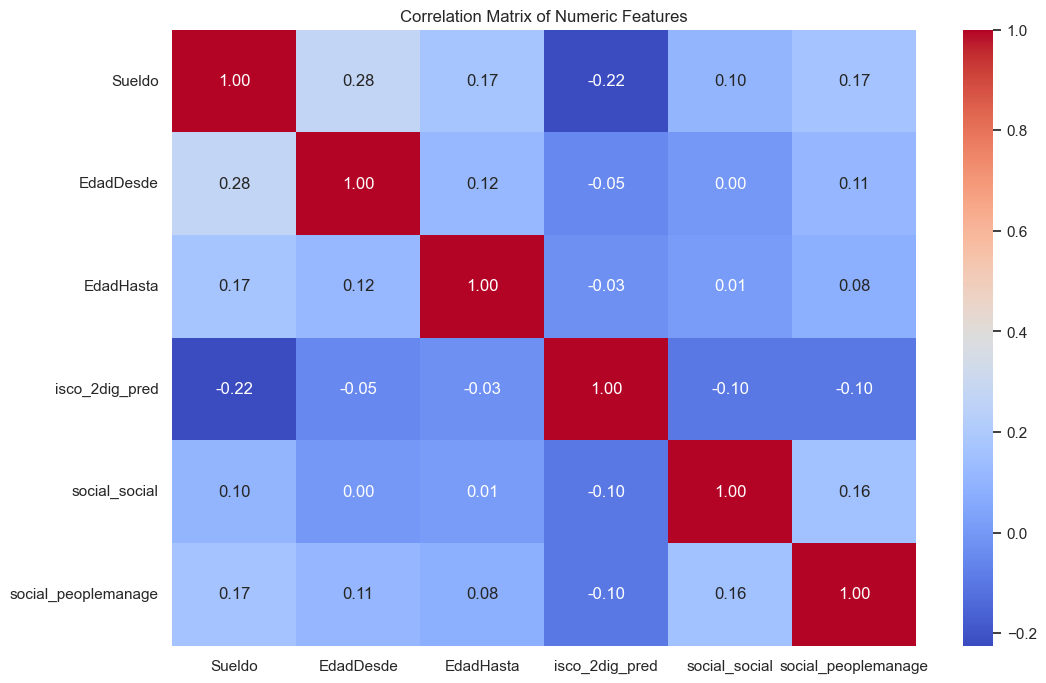

In [5]:
# perform EDA

sns.set(style="whitegrid")

# Histograms for continuous features
print('Histograms for continuous features\n')
vax_df[["year", "EdadDesde","EdadHasta","isco_2dig_pred","num_words"]].hist(bins=15, figsize=(15, 6))
plt.show()


# Count plots for categorical features
print('Count plots for categorical features\n')
fig, ax = plt.subplots(2, 3, figsize=(15, 6))  # Adjust shape according to number of categorical features
for var, subplot in zip(categorical_features[1:-1], ax.flatten()):
    sns.countplot(vax_df[var], ax=subplot)
    for label in subplot.get_xticklabels():
        label.set_rotation(45)
plt.tight_layout()
plt.show()

# Exclude non-numeric columns and compute the correlation matrix
numeric_data = vax_df.select_dtypes(include=[np.number])  # This only includes numeric columns
corr_matrix = numeric_data[["Sueldo", "EdadDesde", "EdadHasta",
                            "isco_2dig_pred", "social_social", "social_peoplemanage"]].corr()


# Plot the correlation matrix
print('Correlation matrix\n')
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix of Numeric Features")
plt.show()


In [6]:
#check for missings and outliers
print("Missing values per column:", vax_df.isnull().sum())

Missing values per column: year                           0
EdadDesde                    892
EdadHasta                    977
CantidadPuestosVacantes        0
Confidencial                   0
AreaEstudio1               18451
IdIdioma1                  22196
isco_2dig_pred                20
Sexo                       17769
JornadaLaboral             12012
NombreNivelJerarquico       3163
num_words                      0
highest_GradoEstudio       12500
section_ciiu                4001
cogn_core                      1
cogn_soph                      1
cogn_comp                      1
cogn_software                  1
cogn_mlai                      1
cogn_finance                   1
cogn_writing                   1
cogn_manage                    1
social_character               1
social_social                  1
social_peoplemanage            1
social_customer                1
manual_fingerdexterity         1
manual_coordination            1
manual_physical                1
Sueldo          

In [7]:
# data preprocessing
# handle NAs
# Numerical columns to impute with median
numerical_cols = ['year', 'EdadDesde', 'EdadHasta', 'num_words',
'CantidadPuestosVacantes']

# Categorical columns to impute with most frequent value
categorical_cols = [col for col in vax_df.columns if col not in
numerical_cols + ['Sueldo']]

# Fill numerical missing values with median
for col in numerical_cols:
    if vax_df[col].isnull().any():
        median_value = vax_df[col].median()
        vax_df[col] = vax_df[col].fillna(median_value)

# Fill categorical missing values with mode
for col in categorical_cols:
    if vax_df[col].isnull().any():
        mode_value = vax_df[col].mode()[0]
        print(col, mode_value)
        vax_df[col] = vax_df[col].fillna(mode_value)

# one hot encode categorial variables
vax_cat = pd.get_dummies(vax_df, columns=categorical_features)

for col in vax_cat.columns:
    if vax_cat[col].dtype == bool:
        vax_cat[col] = vax_cat[col].astype(int)


continuous_features = continuous_features[:22]

features = vax_cat.drop("Sueldo", axis=1)
labels = np.log(vax_cat['Sueldo'].values)

X_train_val, X_test, y_train_val, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_val_scaled[continuous_features] = scaler.transform(X_val[continuous_features])
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])

def to_tensor(X_df, y_array):
    X_tensor = torch.tensor(X_df.values, dtype=torch.float32)
    y_tensor = torch.tensor(y_array, dtype=torch.float32)
    return X_tensor, y_tensor

X_train_tensor, y_train_tensor = to_tensor(X_train_scaled, y_train)
X_val_tensor, y_val_tensor = to_tensor(X_val_scaled, y_val)
X_test_tensor, y_test_tensor = to_tensor(X_test_scaled, y_test)

AreaEstudio1 Administracion de Empresas
IdIdioma1 Inglés
isco_2dig_pred 52.0
Sexo Male
JornadaLaboral Completa
NombreNivelJerarquico Empleado
highest_GradoEstudio Secondary education
section_ciiu G - Wholesale and retail trade; repair of motor vehicles and motorcycles
cogn_core 0.0
cogn_soph 0.0
cogn_comp 0.0
cogn_software 0.0
cogn_mlai 0.0
cogn_finance 0.0
cogn_writing 0.0
cogn_manage 0.0
social_character 0.0
social_social 0.0
social_peoplemanage 0.0
social_customer 1.0
manual_fingerdexterity 0.0
manual_coordination 0.0
manual_physical 0.0


In [8]:
#MODEL ARCHITECTURE DEFINITION AND INITIALIZATION
from torchsummary import summary
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# first MLP
class MLP_Classifier(nn.Module):
    def __init__(self):
        super(MLP_Classifier, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(X_train_tensor.shape[1], 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.layers(x)

model1 = MLP_Classifier().to(device)

#summary of model structure
summary(model1, input_size=(X_train_tensor.shape))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1            [-1, 17178, 16]           3,312
              ReLU-2            [-1, 17178, 16]               0
            Linear-3             [-1, 17178, 1]              17
Total params: 3,329
Trainable params: 3,329
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 13.50
Forward/backward pass size (MB): 4.32
Params size (MB): 0.01
Estimated Total Size (MB): 17.84
----------------------------------------------------------------


In [9]:
class MLP_2(nn.Module):
    def __init__(self):
        super(MLP_2, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(X_train_tensor.shape[1], 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.layers(x)

model2 = MLP_2().to(device)

#summary of model structure
summary(model2, input_size=(X_train_tensor.shape))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1           [-1, 17178, 256]          52,992
              ReLU-2           [-1, 17178, 256]               0
           Dropout-3           [-1, 17178, 256]               0
            Linear-4           [-1, 17178, 128]          32,896
              ReLU-5           [-1, 17178, 128]               0
           Dropout-6           [-1, 17178, 128]               0
            Linear-7            [-1, 17178, 64]           8,256
              ReLU-8            [-1, 17178, 64]               0
            Linear-9            [-1, 17178, 16]           1,040
             ReLU-10            [-1, 17178, 16]               0
           Linear-11             [-1, 17178, 1]              17
Total params: 95,201
Trainable params: 95,201
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 13.50
Forward/b

In [10]:
class MLP_3(nn.Module):
    def __init__(self):
        super(MLP_3, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(X_train_tensor.shape[1], 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.layers(x)

model3 = MLP_3().to(device)

#summary of model structure
summary(model3, input_size=(X_train_tensor.shape))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1           [-1, 17178, 128]          26,496
              ReLU-2           [-1, 17178, 128]               0
            Linear-3            [-1, 17178, 64]           8,256
              ReLU-4            [-1, 17178, 64]               0
            Linear-5             [-1, 17178, 1]              65
Total params: 34,817
Trainable params: 34,817
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 13.50
Forward/backward pass size (MB): 50.46
Params size (MB): 0.13
Estimated Total Size (MB): 64.09
----------------------------------------------------------------


In [11]:
#MODEL TRAINING

#training model function
def train_model(epochs, model, optimizer, criterion, train_loader, val_loader):
    train_losses = []
    val_losses = []
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target.view(-1, 1))
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_losses.append(train_loss / len(train_loader))

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = criterion(output, target.view(-1, 1))
                val_loss += loss.item()
        val_losses.append(val_loss / len(val_loader))
        print(f'Epoch: {epoch+1}, Training Loss: {train_loss / len(train_loader):.4f}, Validation Loss: {val_loss / len(val_loader):.4f}')

    return train_losses, val_losses

In [12]:
#hyperparameter
batch_size = 128

# Create TensorDatasets and DataLoaders for Training
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


criterion = nn.MSELoss()

optimizer1 = optim.Adam(model1.parameters(), lr=0.001)
optimizer2 = optim.Adam(model2.parameters(), lr=0.0001)
optimizer3 = optim.Adam(model3.parameters(), lr=0.0008)

Epoch: 1, Training Loss: 85.2764, Validation Loss: 57.2290
Epoch: 2, Training Loss: 27.2193, Validation Loss: 6.0288
Epoch: 3, Training Loss: 1.7072, Validation Loss: 0.3849
Epoch: 4, Training Loss: 0.3196, Validation Loss: 0.2721
Epoch: 5, Training Loss: 0.2434, Validation Loss: 0.2193
Epoch: 6, Training Loss: 0.2028, Validation Loss: 0.1906
Epoch: 7, Training Loss: 0.1822, Validation Loss: 0.1777
Epoch: 8, Training Loss: 0.1727, Validation Loss: 0.1708
Epoch: 9, Training Loss: 0.1677, Validation Loss: 0.1660
Epoch: 10, Training Loss: 0.1632, Validation Loss: 0.1624
Epoch: 11, Training Loss: 0.1592, Validation Loss: 0.1590
Epoch: 12, Training Loss: 0.1568, Validation Loss: 0.1573
Epoch: 13, Training Loss: 0.1552, Validation Loss: 0.1549
Epoch: 14, Training Loss: 0.1533, Validation Loss: 0.1534
Epoch: 15, Training Loss: 0.1522, Validation Loss: 0.1518
Epoch: 16, Training Loss: 0.1507, Validation Loss: 0.1511
Epoch: 17, Training Loss: 0.1497, Validation Loss: 0.1500
Epoch: 18, Training 

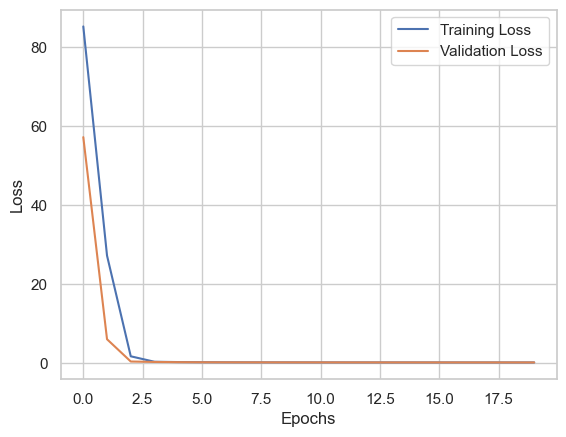

In [13]:
# Run training and plot losses batch size 128
train_losses, val_losses = train_model(20, model1, optimizer1, criterion, train_loader, val_loader)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Epoch: 1, Training Loss: 98.3208, Validation Loss: 52.6111
Epoch: 2, Training Loss: 8.2289, Validation Loss: 0.4582
Epoch: 3, Training Loss: 1.2535, Validation Loss: 0.3495
Epoch: 4, Training Loss: 1.1708, Validation Loss: 0.3086
Epoch: 5, Training Loss: 1.1309, Validation Loss: 0.2817
Epoch: 6, Training Loss: 1.0842, Validation Loss: 0.2553
Epoch: 7, Training Loss: 1.0517, Validation Loss: 0.2424
Epoch: 8, Training Loss: 1.0033, Validation Loss: 0.2257
Epoch: 9, Training Loss: 0.9931, Validation Loss: 0.2278
Epoch: 10, Training Loss: 0.9830, Validation Loss: 0.2092
Epoch: 11, Training Loss: 0.9393, Validation Loss: 0.2332
Epoch: 12, Training Loss: 0.9221, Validation Loss: 0.2316
Epoch: 13, Training Loss: 0.9063, Validation Loss: 0.2205
Epoch: 14, Training Loss: 0.8764, Validation Loss: 0.1984
Epoch: 15, Training Loss: 0.8604, Validation Loss: 0.2474
Epoch: 16, Training Loss: 0.8524, Validation Loss: 0.2330
Epoch: 17, Training Loss: 0.8244, Validation Loss: 0.2937
Epoch: 18, Training L

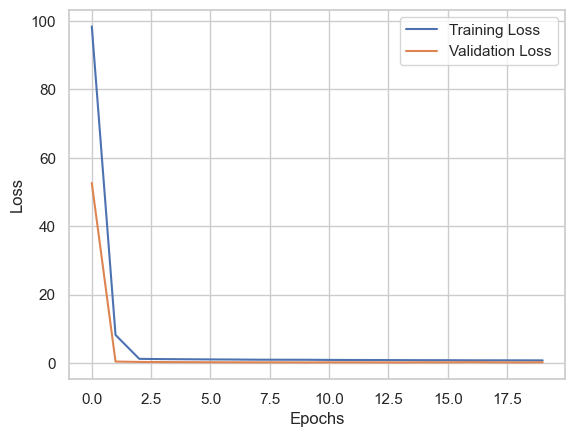

In [14]:
# Run training and plot losses batch size 512
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


train_losses, val_losses = train_model(20, model2, optimizer2, criterion, train_loader, val_loader)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Epoch: 1, Training Loss: 28.4732, Validation Loss: 0.2682
Epoch: 2, Training Loss: 0.2267, Validation Loss: 0.2064
Epoch: 3, Training Loss: 0.1878, Validation Loss: 0.1809
Epoch: 4, Training Loss: 0.1704, Validation Loss: 0.1714
Epoch: 5, Training Loss: 0.1618, Validation Loss: 0.1655
Epoch: 6, Training Loss: 0.1555, Validation Loss: 0.1622
Epoch: 7, Training Loss: 0.1510, Validation Loss: 0.1557
Epoch: 8, Training Loss: 0.1487, Validation Loss: 0.1591
Epoch: 9, Training Loss: 0.1458, Validation Loss: 0.1581
Epoch: 10, Training Loss: 0.1439, Validation Loss: 0.1523
Epoch: 11, Training Loss: 0.1431, Validation Loss: 0.1593
Epoch: 12, Training Loss: 0.1416, Validation Loss: 0.1547
Epoch: 13, Training Loss: 0.1405, Validation Loss: 0.1530
Epoch: 14, Training Loss: 0.1382, Validation Loss: 0.1535
Epoch: 15, Training Loss: 0.1373, Validation Loss: 0.1571
Epoch: 16, Training Loss: 0.1357, Validation Loss: 0.1506
Epoch: 17, Training Loss: 0.1348, Validation Loss: 0.1499
Epoch: 18, Training Lo

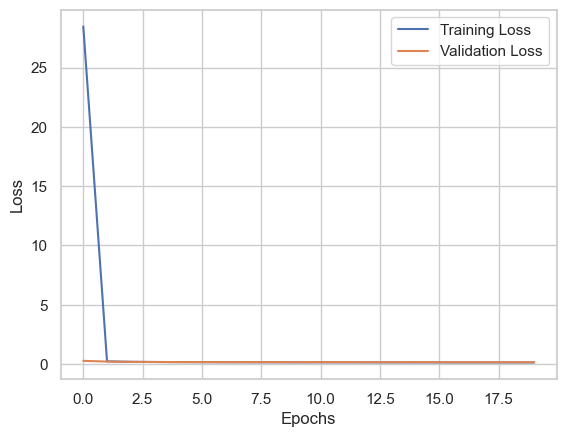

In [15]:
# Run training and plot losses
train_losses, val_losses = train_model(20, model3, optimizer3, criterion, train_loader, val_loader)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [16]:
# model eval on validation set 
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

def evaluate_regression_model(data_loader, model):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for data, target in data_loader:
            data = data.to(device)
            output = model(data)
            y_pred.extend(output.view(-1).cpu().numpy())
            y_true.extend(target.cpu().numpy())

    mape = mean_absolute_percentage_error(np.exp(y_true), np.exp(y_pred))
    mae = mean_absolute_error(np.exp(y_true), np.exp(y_pred))
    mse = mean_squared_error(np.exp(y_true), np.exp(y_pred))

    print(f"Mean absolute percentage error (MAPE): {mape:.4f}")
    print(f"Mean squared error (MSE): {mse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")

    return mse, mae, mape 

print("Model 1 on Validation set:")
mse, mae, mape = evaluate_regression_model(val_loader, model1)
print("\nModel 2 on Validation set:")
mse, mae, mape = evaluate_regression_model(val_loader, model2)
print("\nModel 3 on Validation set:")
mse, mae, mape = evaluate_regression_model(val_loader, model3)

# the most important metrics with mse and mae are the lowest in the third model. R^2 score can be ignored 

Model 1 on Validation set:
Mean absolute percentage error (MAPE): 0.3455
Mean squared error (MSE): 177735216.0000
Mean Absolute Error (MAE): 9119.3418

Model 2 on Validation set:
Mean absolute percentage error (MAPE): 0.3839
Mean squared error (MSE): 313508864.0000
Mean Absolute Error (MAE): 13042.5732

Model 3 on Validation set:
Mean absolute percentage error (MAPE): 0.3510
Mean squared error (MSE): 174155424.0000
Mean Absolute Error (MAE): 9248.6885


In [17]:
print("Model 1 on test set:")
mse, mae, mape = evaluate_regression_model(test_loader, model1)
print("\nModel 2 on test set:")
mse, mae, mape = evaluate_regression_model(test_loader, model2)
print("\nModel 3 on test set:")
mse, mae, mape = evaluate_regression_model(test_loader, model3)

Model 1 on test set:
Mean absolute percentage error (MAPE): 0.3350
Mean squared error (MSE): 192474464.0000
Mean Absolute Error (MAE): 9331.1611

Model 2 on test set:
Mean absolute percentage error (MAPE): 0.3770
Mean squared error (MSE): 323435040.0000
Mean Absolute Error (MAE): 13389.2803

Model 3 on test set:
Mean absolute percentage error (MAPE): 0.3440
Mean squared error (MSE): 184839072.0000
Mean Absolute Error (MAE): 9534.0049


Model 1:


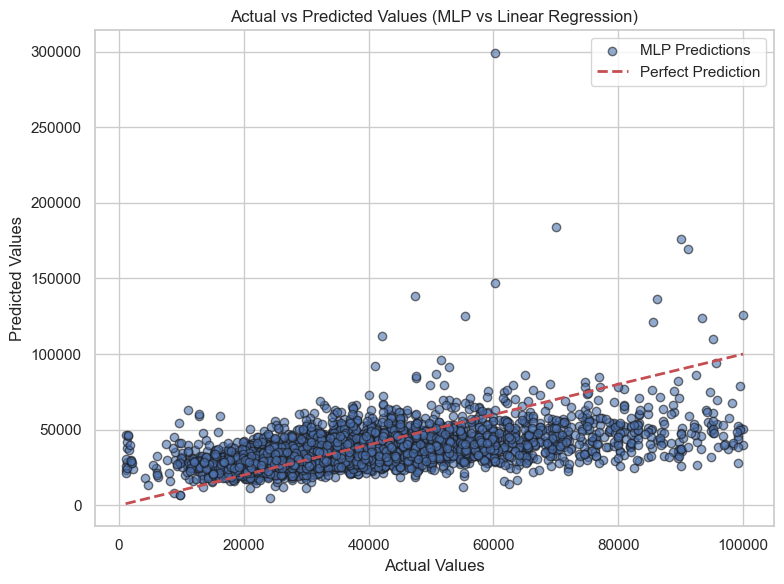

In [18]:
# visualization

def visualize_regression_models(data_loader, model):
    model.eval()
    y_true = []
    y_pred_nn = []

    with torch.no_grad():
        for data, target in data_loader:
            data = data.to(device)
            output = model(data)
            y_pred_nn.extend(output.view(-1).cpu().numpy())
            y_true.extend(target.cpu().numpy())

    # Plot all
    plt.figure(figsize=(8, 6))
    plt.scatter(np.exp(y_true), np.exp(y_pred_nn), alpha=0.6, edgecolors='k', label='MLP Predictions')
    plt.plot([min(np.exp(y_true)), max(np.exp(y_true))], [min(np.exp(y_true)), max(np.exp(y_true))], 'r--', lw=2, label='Perfect Prediction')

    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Actual vs Predicted Values (MLP vs Linear Regression)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# model 1 best model
print("Model 1:")
visualize_regression_models(test_loader, model1)


# print("Model 2:")
# visualize_regression_models(test_loader, model2)
# print("Model 3:")
# visualize_regression_models(test_loader, model3)

    

/var/folders/2b/t_2npzz9457g70yc87zmq03w0000gn/T/ipykernel_80949/4254595541.py:3: RuntimeWarning: overflow encountered in exp
  y_pred = np.exp(lr_model.predict(X_test_scaled))


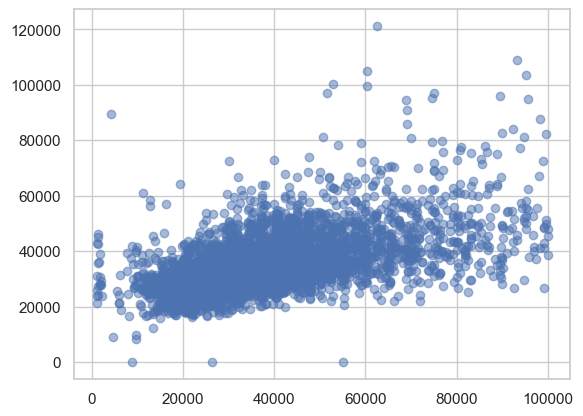

In [19]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred = np.exp(lr_model.predict(X_test_scaled))

plt.scatter(np.exp(y_test), y_pred, alpha=0.5)
plt.show()


# NOTE:  printing the metrics does not work


# mape = mean_absolute_percentage_error(np.exp(y_test), y_pred)
# mae = mean_absolute_error(np.exp(y_test), y_pred)
# mse = mean_squared_error(np.exp(y_test), y_pred)

In [ ]:
# bonus1: Train a Random Forest Regressor and compare its performance with the MLP
from sklearn.ensemble import RandomForestRegressor

regressor = RandomForestRegressor(n_estimators=100, random_state=42, oob_score=True)

regressor.fit(X_train_scaled,y_train)

y_val_pred_rf = regressor.predict(X_test_scaled)

mse = mean_squared_error(np.exp(y_test), np.exp(y_val_pred_rf))
mape = mean_absolute_percentage_error(np.exp(y_test), np.exp(y_val_pred_rf))
mae = mean_absolute_error(np.exp(y_test), np.exp(y_val_pred_rf))

print(f"mean absolute precentage error: {mape:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")

print("\nModel 1:")
mse, mae, mape = evaluate_regression_model(test_loader, model1)

mean absolute precentage error: 0.2836
Mean Squared Error: 135529799.2926
Mean Absolute Error: 7737.4938
Model 1:
Mean absolute percentage error (MAPE): 0.3350
Mean squared error (MSE): 192474464.0000
Mean Absolute Error (MAE): 9331.1611


In [21]:
# bonus2: Model Ensemble
def evaluate_ensemble_regression(data_loader, model1, model2, model3):

    model1.eval()
    model2.eval()
    model3.eval()
    
    y_true = []
    y_pred_ensemble = []

    with torch.no_grad():
        for data, target in data_loader:
            data = data.to(device)
            

            output1 = model1(data)
            output2 = model2(data)
            output3 = model3(data)
            

            ensemble_output = (output1 + output2 + output3) / 3.0
            

            y_pred_ensemble.extend(ensemble_output.view(-1).cpu().numpy())
            y_true.extend(target.cpu().numpy())


    mape = mean_absolute_percentage_error(np.exp(y_true), np.exp(y_pred_ensemble))
    mae = mean_absolute_error(np.exp(y_true), np.exp(y_pred_ensemble))
    mse = mean_squared_error(np.exp(y_true), np.exp(y_pred_ensemble))

    print("=== Ensemble Model Evaluation ===")
    print(f"Mean absolute percentage error (MAPE): {mape:.4f}")
    print(f"Mean squared error (MSE): {mse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")

    return mse, mae, mape

print("\nEnsemble Performance:")
ensemble_metrics = evaluate_ensemble_regression(test_loader, model1, model2, model3)
print("\nBest Model:")
mse, mae, mape = evaluate_regression_model(test_loader, model1)





Ensemble Performance:
=== Ensemble Model Evaluation ===
Mean absolute percentage error (MAPE): 0.3199
Mean squared error (MSE): 200688976.0000
Mean Absolute Error (MAE): 9838.1025

Best Model:
Mean absolute percentage error (MAPE): 0.3350
Mean squared error (MSE): 192474464.0000
Mean Absolute Error (MAE): 9331.1611


/var/folders/2b/t_2npzz9457g70yc87zmq03w0000gn/T/ipykernel_80949/703010881.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  vax_cat["over_30k"] = over_30k


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1            [-1, 17178, 64]          13,312
              ReLU-2            [-1, 17178, 64]               0
            Linear-3             [-1, 17178, 8]             520
              ReLU-4             [-1, 17178, 8]               0
            Linear-5             [-1, 17178, 1]               9
           Sigmoid-6             [-1, 17178, 1]               0
Total params: 13,841
Trainable params: 13,841
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 13.56
Forward/backward pass size (MB): 19.13
Params size (MB): 0.05
Estimated Total Size (MB): 32.75
----------------------------------------------------------------
Epoch: 1, Training Loss: 61.3595, Validation Loss: 63.0294
Epoch: 2, Training Loss: 61.3368, Validation Loss: 63.0294
Epoch: 3, Training Loss: 61.3595, Validation Loss: 

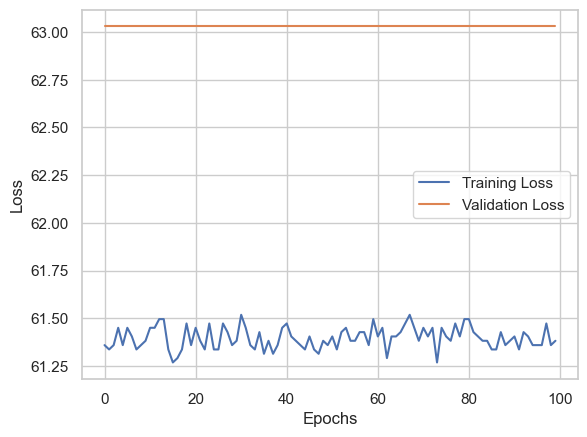

In [22]:
# bonus3: Classification

over_30k = []
for i in vax_cat["Sueldo"]:
    if i > 30000:
        over_30k.append(1)
    else:
        over_30k.append(0)

vax_cat["over_30k"] = over_30k

# Step 3: Split features and labels
features = vax_cat.drop("over_30k", axis=1)
labels = vax_cat["over_30k"].values  # convert to array

# Step 4: Split before scaling
X_train_val, X_test, y_train_val, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

# Step 5: Fit scaler only on training set (only on continuous features)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_val_scaled[continuous_features] = scaler.transform(X_val[continuous_features])
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])

X_train_tensor, y_train_tensor = to_tensor(X_train_scaled, y_train)
X_val_tensor, y_val_tensor = to_tensor(X_val_scaled, y_val)
X_test_tensor, y_test_tensor = to_tensor(X_test_scaled, y_test)


class classification(nn.Module):
    def __init__(self):
        super(classification, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(X_train_tensor.shape[1], 64),
            nn.ReLU(),
            nn.Linear(64, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

model4 = classification().to(device)

#summary of model structure
summary(model4, input_size=(X_train_tensor.shape))


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

criterion = nn.BCELoss()

optimizer4 = optim.Adam(model4.parameters(), lr=0.001)

train_losses, val_losses = train_model(100, model4, optimizer4, criterion, train_loader, test_loader)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()




In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

random_forest_model = RandomForestClassifier(n_estimators=100,random_state=42, max_depth=3)
random_forest_model.fit(X_train_scaled,y_train)

prediction = random_forest_model.predict(X_val_scaled)

accuracy = accuracy_score(y_val, prediction)
precision = precision_score(y_val, prediction)
recall = recall_score(y_val, prediction)
f1 = f1_score(y_val, prediction)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.8945
Precision: 0.8532
Recall: 1.0000
F1 Score: 0.9208


In [24]:
test_predictions = random_forest_model.predict(X_test_scaled)

# Calculate metrics on test set
test_accuracy = accuracy_score(y_test, test_predictions)
test_precision = precision_score(y_test, test_predictions)
test_recall = recall_score(y_test, test_predictions)
test_f1 = f1_score(y_test, test_predictions)

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(data_loader, model=model4):
    model.eval() 
    y_true = []
    y_scores = []


    with torch.no_grad():
        for data, target in data_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            y_scores.extend(output.view(-1).cpu().numpy()) 
            y_true.extend(target.cpu().numpy())

    y_pred = [1 if score >= 0.5 else 0 for score in y_scores]

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print("Evaluation Metrics:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")


    return accuracy,precision,recall,f1


print("\nClassification on test set:")
test_metrics = evaluate_model(test_loader)

print("\n RandomForrest:")
print("Test Set Performance:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1 Score: {test_f1:.4f}")


Classification on test set:
Evaluation Metrics:
Accuracy: 0.3697
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000

 RandomForrest:
Test Set Performance:
Accuracy: 0.9027
Precision: 0.8663
Recall: 1.0000
F1 Score: 0.9284


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
